<a href="https://colab.research.google.com/github/raghavjoshi03/Machine-Learning/blob/tensorFlow/01_neural_network_regression_with_tensorFlow_editted.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Introduction to regression with Neural Networks in TensorFlow

There are many definitions for regression problem but in our case, we are going to simplify it: Predicting a numerical variable based on some other combinations of variables, even shorter... predicting a number.

In [220]:
# Import tensorflow
import tensorflow as tf
print(tf.__version__)

2.20.0


# Creating some data to view and fit

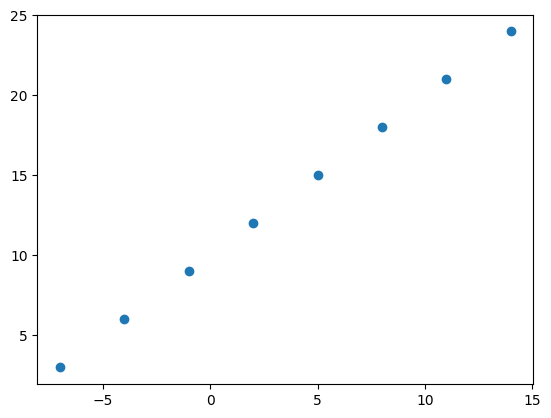

In [221]:
import numpy as np
import matplotlib.pyplot as plt

# Create the features
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Vizualize it
plt.scatter(X, y)

In [222]:
y == X + 10

array([ True,  True,  True,  True,  True,  True,  True,  True])

### Input and Output Shapes

In [223]:
# Create a demo tensor for our housing price prediction problem
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [224]:
X[0], y[0]

(np.float64(-7.0), np.float64(3.0))

In [225]:
X[1], y[1]

(np.float64(-4.0), np.float64(6.0))

In [226]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape

((), ())

In [227]:
X[0].ndim

0

In [228]:
# Turn our Numpy arrays into tensors (and ensure float32 dtype)
X = tf.cast(tf.constant(X), dtype=tf.float32)
y = tf.cast(tf.expand_dims(tf.constant(y), axis=-1), dtype=tf.float32)
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[ 3.],
        [ 6.],
        [ 9.],
        [12.],
        [15.],
        [18.],
        [21.],
        [24.]], dtype=float32)>)

In [229]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape

(TensorShape([]), TensorShape([1]))

### Steps in modelling with tensorFlow

1. **Creating a model**- Define the input and output layers as well as the hidden layers of a deep learning model.

2. **Compiling the model**- Defining the loss function(In other words, in other words the function which tells our model how wrong it is) and the optimizer(tells our model how to improve patterns it's learning) and evalutaion metrics(what we can use to interpret the performance of our model).

3. **Fitting the Model**- Letting the model try to find patterns between X & y (Features and Labels).  

1. Construct or import a pretrained model relevent to your problem

2. Compile the model(prepare it to be used with the data)
* Loss- How wrong your model's predictions are compared to the truth tables.

* Optimizers- How your model should update it's internal patterns to better it's predictions.

* Metrics- Human interpretable values for how well your model is doing.

3. Fit the model to the training data so that it can discover patterns.

* Epochs- How many times the model will go through all of the training examples.

4. Evaluate the model on test data(how reliable are our model's predictions)

In [230]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model using Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1]) # Added input_shape argument
])

# 2. Compile the model
model.compile(loss = tf.keras.losses.mae, #mae is the short for mean absolute error
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"]
              )

# Fit the model
model.fit(X, y, epochs=5)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step - loss: 22.0267 - mae: 22.0267
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 21.6335 - mae: 21.6335
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 21.2404 - mae: 21.2404
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 20.8473 - mae: 20.8473
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 20.4749 - mae: 20.4749


In [231]:
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[ 3.],
        [ 6.],
        [ 9.],
        [12.],
        [15.],
        [18.],
        [21.],
        [24.]], dtype=float32)>)

In [232]:
y_pred = model.predict(tf.constant([[17.0]], dtype=tf.float32))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


array([[-24.142519]], dtype=float32)

In [233]:
y_pred+11

array([[-13.142519]], dtype=float32)

### Improving the model

We can improve our model by improving the steps we took to create a model.

1. ** Creating a Model** - here we might add more layers, increase the number of hidden units(all called neurons) within each of the hidden layers, change the activation functions of each layer.

2. **Compiling the Model** - here we might change the optimization function or perhaps the **learning rate** of the optimization function.

3. **Fitting the model**- here we might fit a model for more **epochs**(leave it training for longer) or on more data (give the model more exmples to learn from).

In [234]:
# Lets rebuild the model

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1]) # Re-added input_shape argument
])

# Compile the model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"])

# Fit the model
model.fit(X, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step - loss: 8.2918 - mae: 8.2918
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - loss: 8.1593 - mae: 8.1593
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - loss: 8.0268 - mae: 8.0268
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - loss: 7.8943 - mae: 7.8943
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - loss: 7.7618 - mae: 7.7618
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - loss: 7.6293 - mae: 7.6293
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - loss: 7.4968 - mae: 7.4968
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - loss: 7.4475 - mae: 7.4475
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - loss: 7.4419 - mae: 7.4419
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - loss: 7.4362 - mae: 7.4362
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - loss: 7.4306 - mae: 7.4306
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - loss: 7.4250 - mae: 7.4250
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━

In [235]:
# Remind ourselves of the data
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[ 3.],
        [ 6.],
        [ 9.],
        [12.],
        [15.],
        [18.],
        [21.],
        [24.]], dtype=float32)>)

In [236]:
# Let's see if our model's prediction has improved
model.predict(tf.constant([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


array([[30.229387]], dtype=float32)

In [237]:
tf.random.set_seed(42)

# Create the model with a single Dense layer for a linear relationship
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape = [1]) # Single neuron for linear output
], name="linear_model") # Give it a descriptive name

# Compile the model
model.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics = ["mae"]
)

# Fit the model on the TRAINING data
model.fit(X, y, epochs=100, verbose=0) # Train on X_train, y_train

In [238]:
# let's remind ourselves of the data
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[ 3.],
        [ 6.],
        [ 9.],
        [12.],
        [15.],
        [18.],
        [21.],
        [24.]], dtype=float32)>)

### Even though our loss and MAE are lower, what it might be doing is overfitting ie. it's learning the training data too well, so it's learning the patterns between X and y far too well so when it sees

In [239]:
# Let's try to make a prediction
model.predict(tf.constant([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


array([[-1.2855985]], dtype=float32)

### Ways to improve the model

1. Adding Layers
2. Inrease the number of hidden units
3. Change the activation Function.
4. Change the optimization functions.
5. Change the learning rate
6. Fitting on more data
7. Fitting for longer.

## Evaluating a model's performance

In practice, a typical workflow you will go through when building a neural network is:

```
Build a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it...
```

When it comes to evaluation there are 3 words you should memorize:

>    "Visualize, Visualize, Visualize"

It's a good idea to visualize:
* What data are we working with? What does it look like?
* The model itself- What does our model look like?
* The training of our model- How does a model perform while it learns.
* The predictions of a model- How do the predictions of a model line up against the ground truth(the orignal labels).

In [240]:
# Make a bigger dataset
X = tf.range(-100, 100, 4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [241]:
# Make labels for the dataset
y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

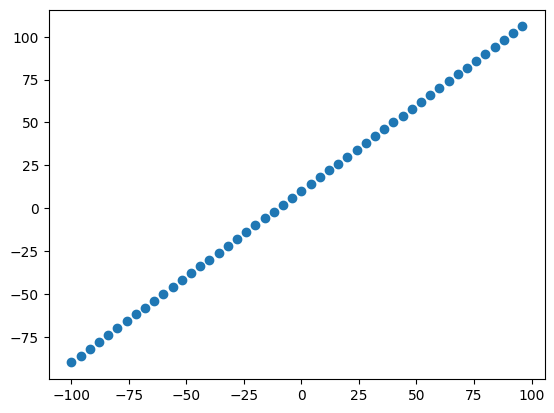

In [242]:
# Visualize the data
import matplotlib.pyplot as plt
plt.scatter(X, y)

### The 3 sets

* **training set**- the model learns from this data which is typically which is typically 70-80% of the total data available.

* **Validation set**- The model gets tuned on this data, which is typically 10-15% of the data available.

* **Test set**- The model gets evaluated on this data to test what it has learned, this set is typiclly 10-15% of the data available.

In [243]:
# check the length of how many samples we have
len(X)

50

In [244]:
# Split the data into train and test sets
X_train = X[:40]
X_test = X[40:]

y_train = y[:40]
y_test = y[40:]

len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

### Visualizing the data

Now we have got our data in training and testing sets... visualize it again.

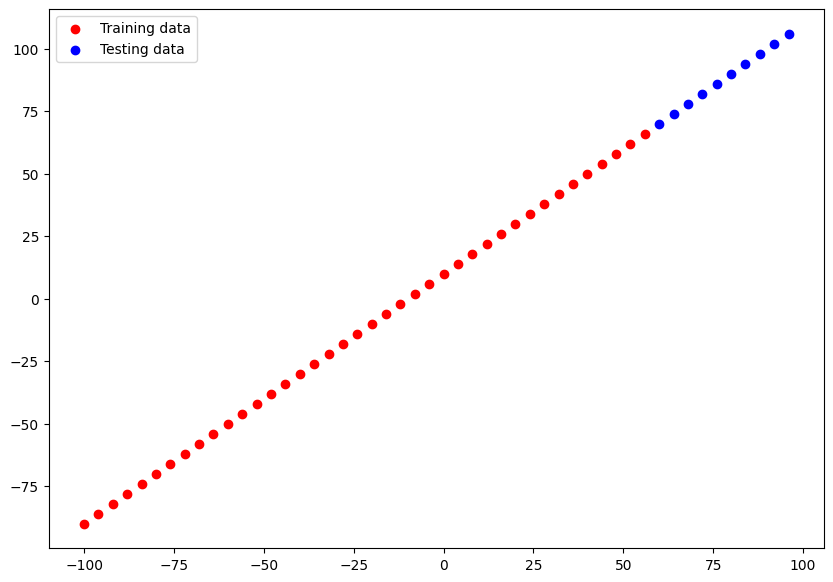

In [245]:
plt.figure(figsize=(10, 7))
# Plot the training data in blue
plt.scatter(X_train, y_train, c="r", label="Training data")
# Plot the testing data in blue
plt.scatter(X_test, y_test, c="b", label="Testing data")
# Show a legend
plt.legend();

In [246]:
# Let's have a look at how to build a Neural Network for our data

# 1. Create a model
model= tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"])

In [247]:
# Visualizing the model
model.summary()

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_59 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [248]:
tf.random.set_seed(42)

# Create a simpler model with a single Dense layer for a linear relationship
model = tf.keras.Sequential([
    tf.keras.Input(shape=[1]), # Define input shape explicitly with Input layer
    tf.keras.layers.Dense(1) # Single neuron for linear output
], name="simple_linear_model") # Give it a descriptive name

# Compile the model
model.compile(loss = tf.keras.losses.mae, #mae is the short for mean absolute error
              optimizer = tf.keras.optimizers.SGD(),
              metrics=["mae"])

# Fit the model
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 103.5537 - mae: 103.5537 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 68.7782 - mae: 68.7782
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 34.1930 - mae: 34.1930
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 8.5679 - mae: 8.5679
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 9.3065 - mae: 9.3065
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 8.4157 - mae: 8.4157
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 8.9309 - mae: 8.9309
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 8.8195 - mae: 8.8195
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 8.5514 - mae: 8.5514
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 9.3118 - mae: 9.3118
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 8.3992 - mae: 8.3992
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 9.0899 - mae: 9.0899
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s

In [249]:
model.summary()

Model: "simple_linear_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

* total params-Total number of parameters in the model.
* trainable parameters- these are the parameters that the model can update(train) as it trains.
* Non trainable pramaters- these parameters aren't updated duraing training (this is typical when you bring in already learn patternsor parametersfrom other models during **transfer learning**).

⛏ **Exercise**- Try playing around with the number of hidden units in a Dense layer, see how that effets the number of parameters(total and trainable) by calling the model.summary().

📚 **Resources**: For more in-depth overview of the trainable parameters within a layer, check out MIT's introduction to deep learning video.

In [250]:
# Let's fit our model to the training data
model.fit(X_train, y_train, epochs=100, verbose=0)

In [251]:
# Get a summary of our model
model.summary()

Model: "simple_linear_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

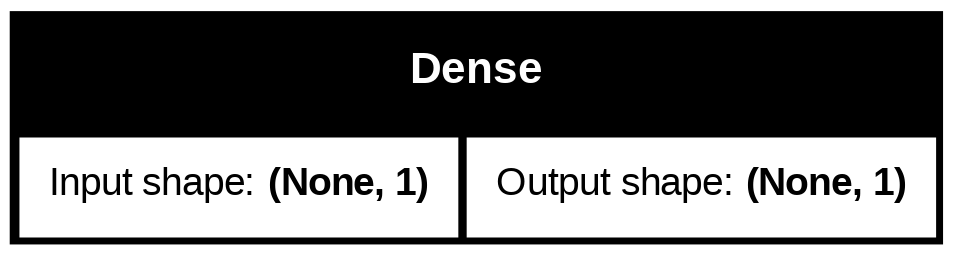

In [252]:
from tensorflow.keras.utils import plot_model

plot_model(model=model, show_shapes=True)

### Visualizing our model's Prediction

To visualize predictions it's good idea to plotbthem against the grund truth labels.

Often you will see this in the form `y_test` or `y_true` versus `y_pred`(ground truth versus your model's predictions)

In [253]:
# Make so predictions
y_pred = model.predict(X_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


array([[ 72.471146],
       [ 77.120255],
       [ 81.76938 ],
       [ 86.41849 ],
       [ 91.06761 ],
       [ 95.71672 ],
       [100.365845],
       [105.01497 ],
       [109.66408 ],
       [114.3132  ]], dtype=float32)

Now, let's evaluate the model on the test set using the Mean Absolute Error (MAE) metric, which was defined during model compilation.

In [254]:
# Evaluate the model on the test data
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 5.3922 - mae: 5.3922


[5.392168998718262, 5.392168998718262]

Finally, let's visualize these predictions against the true test labels.

In [255]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

🔑 **Note**- If you are going to use some kind of functionality in the future it is a good idea to turn it into a function.

In [256]:
# Let's create a plotting function

def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = y_pred
                     ):
  """Plots the training data, testing data and compares the predictions to the ground truth labels"""
  plt.figure(figsize=(10, 7))

  #plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="Training Data")
  # plot testing data in Green
  plt.scatter(test_data, test_labels, c="g", label="Testing Data")
  # plot model's prediction in red
  plt.scatter(test_data, predictions, c="r", label="Predictions")
  # Show the legend
  plt.legend();
  plt.show() # Added to ensure the plot is displayed

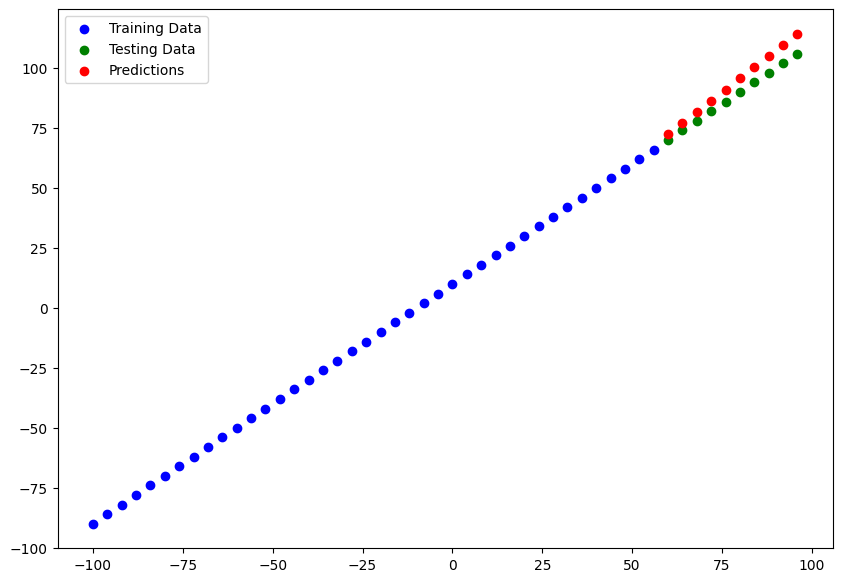

In [257]:
plot_predictions(train_data = X_train,
                 train_labels=y_train,
                 test_data=X_test,
                 test_labels=y_test,
                 predictions=y_pred)

### Evaluating our model's predictions with regression evaluation metrics.

Depending on the problem you are working on, there will be different evaluation metrics to evaluate your model's performance.

Since we are working on a regression problem, two of the main metrics:

* MAE - Mean Absolute Error, "on average, how wrong is each of my model's predictions"

* MSE- Mean Square Error, "square the average errors"



In [258]:
# Evaluate the model on test set
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 5.3922 - mae: 5.3922


[5.392168998718262, 5.392168998718262]

In [259]:
tf.constant(y_pred)

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[ 72.471146],
       [ 77.120255],
       [ 81.76938 ],
       [ 86.41849 ],
       [ 91.06761 ],
       [ 95.71672 ],
       [100.365845],
       [105.01497 ],
       [109.66408 ],
       [114.3132  ]], dtype=float32)>

In [260]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [261]:
tf.squeeze(y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 72.471146,  77.120255,  81.76938 ,  86.41849 ,  91.06761 ,
        95.71672 , 100.365845, 105.01497 , 109.66408 , 114.3132  ],
      dtype=float32)>

In [262]:
# Calculate the mean absolute error
mae = tf.metrics.MAE(y_true=y_test, y_pred=tf.squeeze(y_pred))
mae

<tf.Tensor: shape=(), dtype=float32, numpy=5.392168998718262>

In [263]:
# Calculate the mean Square error
mse = tf.metrics.MSE(y_true=y_test, y_pred=tf.squeeze(y_pred))
mse

<tf.Tensor: shape=(), dtype=float32, numpy=32.55165481567383>

In [264]:
# Let's use some functions to reuse the MSE and MAE
def mae(y_true, y_pred):
  return tf.metrics.MAE(y_true=y_true, y_pred=y_pred)

def mse(y_true, y_pred):
  return tf.metrics.MSE(y_true=y_true, y_pred=y_pred)

### Running experiments to improve our model

```
Build a model-> fit it -> evaluate it -> tweak it -> fit it -> evaluate it -> tweak it-> fit it -> evaluate it....
```

1. Get more data - get more examples for your model to train on(more opportunities to learn patterns or relationships between features and labels).
2. Make your model larger(using a more complex model) -this might come in form of layers or more hidden units in each layers.
3. Train for longer- give your model more of a chance to find patterns in the data.

Let's do 3 modelling experiments:
1. `model_1`-Same as  the orignal model, 1 layer, trained for 100 epochs.

2. `model_2`- 2 layers trained for 100 epochs.

3. `model_3`- 2 layers trained for 500 epochs.


**Build model_1**

In [265]:
X_train, y_train

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56], dtype=int32)>,
 <tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66], dtype=int32)>)

In [266]:
# Set random seed
tf.random.set_seed(42)

# Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1]) # Add input_shape to specify input dimensions
])

# Compile the model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"])

# Fit the model
model.fit(X_train, y_train, epochs=100)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 28.4506 - mae: 28.4506 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 9.7866 - mae: 9.7866
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 11.1400 - mae: 11.1400
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 8.7531 - mae: 8.7531
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 9.8625 - mae: 9.8625
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 11.2696 - mae: 11.2696
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 8.8290 - mae: 8.8290
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 9.9384 - mae: 9.9384  
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 11.3993 - mae: 11.3993 
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 8.9048 - mae: 8.9048
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 10.0142 - mae: 10.0142
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 11.5289 - mae: 11.5289 
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44m

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


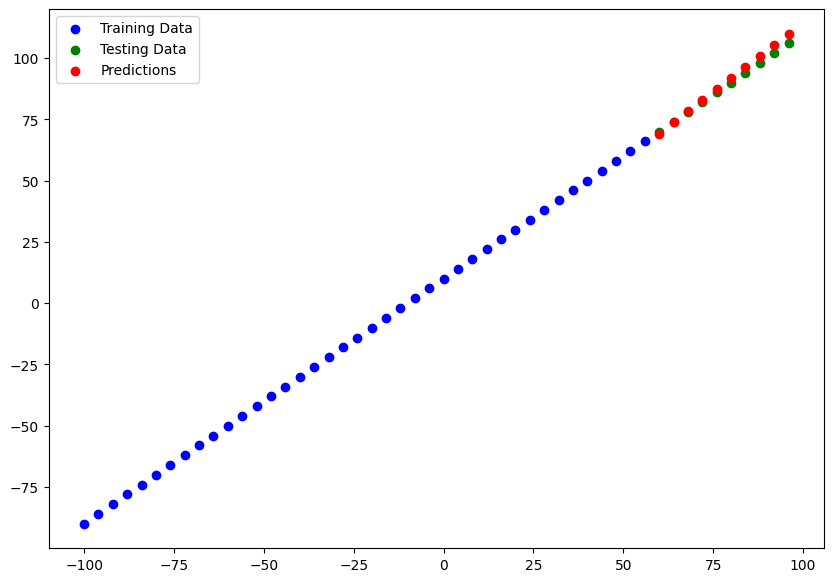

In [267]:
# Make and plot predictions for model
y_pred = model.predict(X_test)
plot_predictions(predictions=y_pred)

In [268]:
tf.constant(y_pred), tf.squeeze(y_pred)

(<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
 array([[ 69.23645],
        [ 73.75763],
        [ 78.27881],
        [ 82.79999],
        [ 87.32117],
        [ 91.84235],
        [ 96.36353],
        [100.88471],
        [105.40589],
        [109.92707]], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 69.23645,  73.75763,  78.27881,  82.79999,  87.32117,  91.84235,
         96.36353, 100.88471, 105.40589, 109.92707], dtype=float32)>)

In [269]:
# Calculate model evaluation metrics
mae1 = mae(y_test, tf.squeeze(y_pred))
mse1 = mse(y_test, tf.squeeze(y_pred))
mae1, mse1

(<tf.Tensor: shape=(), dtype=float32, numpy=1.7829437255859375>,
 <tf.Tensor: shape=(), dtype=float32, numpy=4.742901802062988>)

**Build `model_2`**

* 2 Dense layers for 100 epochs

In [270]:
# Set random seed
tf.random.set_seed(42)

# Create the model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1]),
    tf.keras.layers.Dense(1)
])

# Compiling the model
model_2.compile(loss = tf.keras.losses.mae,
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.01), # Changed optimizer to Adam
                metrics = ["mse"])

# Fit the model
model_2.fit(X_train, y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 62.1819 - mse: 5319.7847 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 55.4061 - mse: 4212.9873
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 48.8811 - mse: 3267.8862
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 42.6054 - mse: 2470.7124
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 36.5239 - mse: 1808.0531
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 30.6623 - mse: 1267.0552
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 24.9784 - mse: 837.2444
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 19.5863 - mse: 510.3350
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 14.4244 - mse: 280.6721
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 9.9508 - mse: 142.8784 
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 8.1721 - mse: 91.0970
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 10.0953 - mse: 102.7038
Epoch 13

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


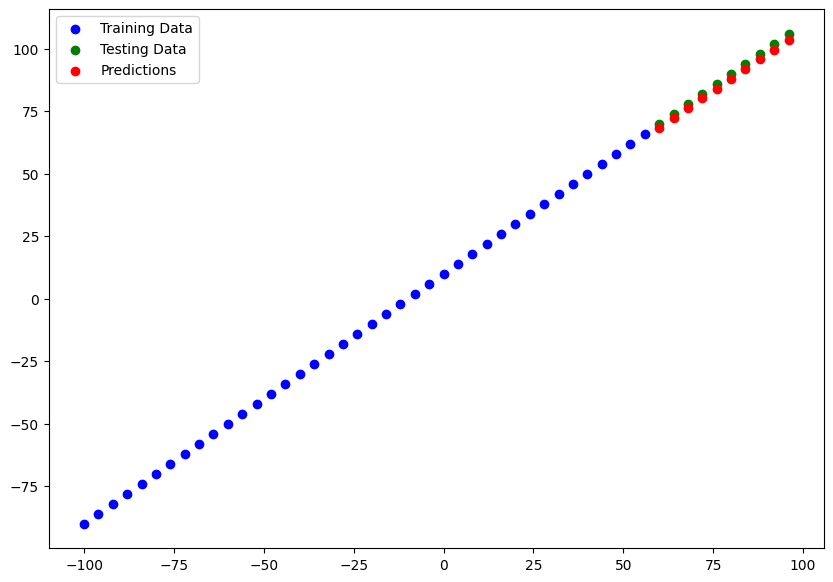

In [271]:
# Make and plot predictions of model_2
y_preds_2 = model_2.predict(X_test)
plot_predictions(predictions=y_preds_2)

In [272]:
# Calculate model_2 evaluation metrics
mae_2 = mae(y_test, tf.squeeze(y_preds_2))
mse_2 = mse(y_test, tf.squeeze(y_preds_2))
mae_2, mse_2

(<tf.Tensor: shape=(), dtype=float32, numpy=2.0199248790740967>,
 <tf.Tensor: shape=(), dtype=float32, numpy=4.159754753112793>)

In [273]:
mae2 = mae(y_test, tf.squeeze(y_preds_2))
mse2 = mse(y_test, tf.squeeze(y_preds_2))
mae2, mse2

(<tf.Tensor: shape=(), dtype=float32, numpy=2.0199248790740967>,
 <tf.Tensor: shape=(), dtype=float32, numpy=4.159754753112793>)

**Build `model_3`**

* 2 layers, trained for 500 epochs

In [274]:
# Set the random seed
tf.random.set_seed(42)

# Create a model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1]),
    tf.keras.layers.Dense(1)
])

# Compile the model
model_3.compile(loss = tf.keras.losses.mae,
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.01), # Set learning rate to 0.01
                metrics = ["mse"])

# Fit the model (correctly train model_3)
model_3.fit(X_train, y_train, epochs=500)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 67.9161 - mse: 6358.5498 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 61.5602 - mse: 5212.3955
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 55.4282 - mse: 4216.3076
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 49.5354 - mse: 3357.5664
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 43.8919 - mse: 2624.8169
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 38.4473 - mse: 2006.0039
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 33.1936 - mse: 1489.4557
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 28.1420 - mse: 1064.7346
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 23.2335 - mse: 722.7249
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 18.5386 - mse: 457.1575
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 14.0047 - mse: 264.6835
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 9.9806 - mse: 143.1222 
Epoc

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


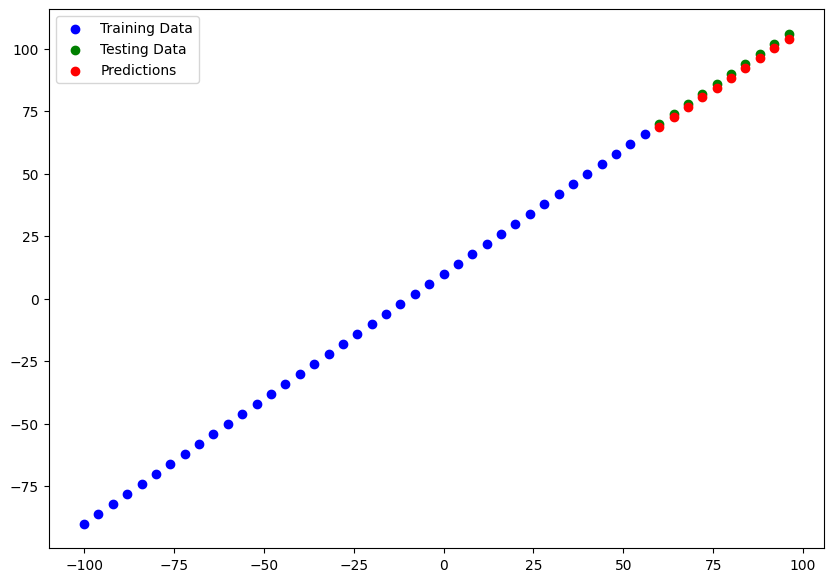

In [275]:
# Make and plot some predictions
y_preds_3 = model_3.predict(X_test)
plot_predictions(predictions=y_preds_3)

In [276]:
mae3 = mae(y_test, tf.squeeze(y_preds_3))
mse3 = mse(y_test, tf.squeeze(y_preds_3))
mae3, mse3

(<tf.Tensor: shape=(), dtype=float32, numpy=1.5376335382461548>,
 <tf.Tensor: shape=(), dtype=float32, numpy=2.415132522583008>)

## Comparing the results of our experiments

We have run a few expriments, let's compare our results.

🔑 **Note** You want to start with small experiments(small models) and make sure they work and then increase their scale when necessary.

In [277]:
# Let's compare our model's results using pandas DataFrame
import pandas as pd

model_results = [["model_", mae1.numpy(), mse1.numpy()],
                 ["model_2", mae2.numpy(), mse2.numpy()],
                 ["model_3", mae3.numpy(), mse3.numpy()]]

all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results

,model,mae,mse
0,model_,1.782944,4.742902
1,model_2,2.019925,4.159755
2,model_3,1.537634,2.415133


In [278]:
model_3.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

> 🔑 **Note** One of your main goals should be to minimize the time between your experiments. The more experiments you do, the more things you will figure out which don't work and in turn get closer tofiguring out what does work. Remember the Machine Learning Practioner's motto: "experiment, experiment, experiment".

## Tracking your experiments

One really good habit in Machine Learning modelling is to track the results of your experiments.

And when doing so, it can be tedious if you are running lots of experiments.

Luckily there are tools to help us!

📖**Resource:** As you build more models, you will look into using:

* TensorBoard- A component of the TensorFlow Library to help track modelling experiments(we will see this one later).

* Weights and Biases- A tool for tracking all kinds of Machine Learning experiments(Plugs straight into TensorBoard).  

### Saving our Models.

Saving our models allows us to use them outside of Google Colab(or wherever they were trained) such as in web application or a mobile app.

There are two main formats whwere we can save our models too:

1. The SavedModel Format.
2. The HDF5 Model Format.

In [279]:
# Save Model using SavedModel Format
model_3.export("best_model_Saved_Model_format")

Saved artifact at 'best_model_Saved_Model_format'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_98')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135864339455184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135864339462288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135864339455760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135864339449808: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [280]:
# Save the model using HDF5 format
model_3.save("best_model_HDF5_format.h5")

### Loading in a saved model


In [281]:
# # Load in the savedModel format model
# loaded_SavedModel_format = tf.keras.models.load_model("/content/best_model_Saved_Model_format")
# loaded_SavedModel_format.summary()

In [282]:
# Load the model saved in HDF5 format using tf.keras.models.load_model()
loaded_h5_model = tf.keras.models.load_model("best_model_HDF5_format.h5")
loaded_h5_model.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [283]:
model_3.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

In [284]:
model_3_preds = model_3.predict(X_test)
loaded_h5_model_preds = loaded_h5_model.predict(X_test)
model_3_preds == loaded_h5_model_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [285]:
mae(y_true=y_test, y_pred=model_3_preds) == mae(y_true=y_test, y_pred=loaded_h5_model_preds)

<tf.Tensor: shape=(10,), dtype=bool, numpy=
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])>

In [286]:
model_3_preds, loaded_h5_model_preds

(array([[ 68.81554 ],
        [ 72.73706 ],
        [ 76.65858 ],
        [ 80.58009 ],
        [ 84.501595],
        [ 88.42312 ],
        [ 92.34464 ],
        [ 96.26617 ],
        [100.187675],
        [104.1092  ]], dtype=float32),
 array([[ 68.81554 ],
        [ 72.73706 ],
        [ 76.65858 ],
        [ 80.58009 ],
        [ 84.501595],
        [ 88.42312 ],
        [ 92.34464 ],
        [ 96.26617 ],
        [100.187675],
        [104.1092  ]], dtype=float32))

In [287]:
# Load in a model using the .h5 format
loaded_h5_model1 = tf.keras.models.load_model("/content/best_model_HDF5_format.h5")
loaded_h5_model1.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [288]:
model_3.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

In [289]:
# Check to see if loaded .h5 model predictions match model 3
model_3_preds = model_3.predict(X_test)
loaded_h5_model1_preds = loaded_h5_model1.predict(X_test)
model_3_preds == loaded_h5_model1_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

### Download a model or (any other file) from Google Colab

If you want to download your files from Google Colab:

1. You can go to "files" tab and right click on the file you are and click after and click "download"

2. Use code(See the cell below)

3. Save to Google Drive by connecting it to Google Drive and coping it there(See second code cell below).

In [290]:
# Download a file from Google Colab
from google.colab import files
files.download("/content/best_model_HDF5_format.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [291]:
# Save a file from Google Colab to Google Drive(requires mounting Google Drive)
# !cp /content/best_model_HDF5_format.h5

### A larger example

In [292]:
# Import required libraries
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

In [293]:
# Read the insurance dataset
insurance =pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [294]:
# Let's try one hot encoding our Data Frame so it's all numbers
insurance_one_hot = pd.get_dummies(insurance)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [295]:
# Create X and y values(features and labels)
X = insurance_one_hot.drop("charges", axis=1)
y = insurance_one_hot["charges"]

In [296]:
# View X
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False


In [297]:
# View y
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [298]:
# Create training and test states
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X), len(X_train), len(X_test)

(1338, 1070, 268)

In [299]:
X_train

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
560,46,19.950,2,True,False,True,False,False,True,False,False
1285,47,24.320,0,True,False,True,False,True,False,False,False
1142,52,24.860,0,True,False,True,False,False,False,True,False
969,39,34.320,5,True,False,True,False,False,False,True,False
486,54,21.470,3,True,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1095,18,31.350,4,True,False,True,False,True,False,False,False
1130,39,23.870,5,True,False,True,False,False,False,True,False
1294,58,25.175,0,False,True,True,False,True,False,False,False
860,37,47.600,2,True,False,False,True,False,False,False,True


In [300]:
tf.random.set_seed(42)

# insurance model
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[X_train.shape[1]]), # Changed input_shape to match the number of features in X_train
    tf.keras.layers.Dense(1)
])

# Compile the model
insurance_model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"])

# Fit the model
insurance_model.fit(X_train, y_train, epochs=100)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8680.1025 - mae: 8680.1025  
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7733.0278 - mae: 7733.0278
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7867.6094 - mae: 7867.6094
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7779.6865 - mae: 7779.6865
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7560.8770 - mae: 7560.8770
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7688.1304 - mae: 7688.1304
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7719.5762 - mae: 7719.5762
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7490.5010 - mae: 7490.5010
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7455.0830 - mae: 7455.0830
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7716.1045 - mae: 7716.1045
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7518.2012 - mae: 7518.2012
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 77

In [301]:
# Check the results of the insurance model on the test data
insurance_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8000.1753 - mae: 8000.1753  


[8000.17529296875, 8000.17529296875]

In [302]:
y_train.median(), y_train.mean()

(9575.4421, np.float64(13346.089736364485))

In [303]:
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


### Right now it looks like our model is not performing well... let's try and improve it

To (try) improve our model, we will run 2 experiments:
1. Add an extra layer with more hidden units and use the Adam Optimizer.
2. Same as above but Train for longer(200 epochs).
3. (Insert your own experiment).

In [304]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# Compile the model
insurance_model_2.compile(loss = tf.keras.losses.mae,
                          optimizer = tf.keras.optimizers.Adam(),
                          metrics = ["mae"])

# Fit the model
insurance_model_2.fit(X_train, y_train, epochs=100, verbose=1)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 13229.0107 - mae: 13229.0107
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13003.7715 - mae: 13003.7715
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12542.8652 - mae: 12542.8652
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11690.6562 - mae: 11690.6562
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10407.4238 - mae: 10407.4238
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8974.2607 - mae: 8974.2607
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7867.6992 - mae: 7867.6992
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7483.3140 - mae: 7483.3140
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7427.8779 - mae: 7427.8779
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7406.3530 - mae: 7406.3530
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7385.9507 - mae: 7385.9507
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s

In [305]:
# Evaluate the larger model
insurance_model_2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4718.3613 - mae: 4718.3613  


[4718.361328125, 4718.361328125]

In [306]:
insurance_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8000.1753 - mae: 8000.1753 


[8000.17529296875, 8000.17529296875]

In [307]:
# Set random seed
tf.random.set_seed(42)

# Create a model
insurance_model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model_3.compile(loss = tf.keras.losses.mae,
                          optimizer = tf.keras.optimizers.Adam(),
                          metrics = ["mae"])

# 3. fit the model
history=insurance_model_3.fit(X_train, y_train, epochs=200, verbose=1)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 13266.6318 - mae: 13266.6318
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13065.0410 - mae: 13065.0410
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12661.2246 - mae: 12661.2246
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11900.6211 - mae: 11900.6211
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10685.4004 - mae: 10685.4004
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9234.1094 - mae: 9234.1094
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8008.6982 - mae: 8008.6982
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7497.5928 - mae: 7497.5928
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7428.0273 - mae: 7428.0273
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7406.1084 - mae: 7406.1084
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7385.3354 - mae: 7385.3354
Epoch 12/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s

In [308]:
insurance_model_3.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3392.7561 - mae: 3392.7561  


[3392.756103515625, 3392.756103515625]

In [309]:
insurance_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8000.1753 - mae: 8000.1753 


[8000.17529296875, 8000.17529296875]

Text(0.5, 0, 'epochs')

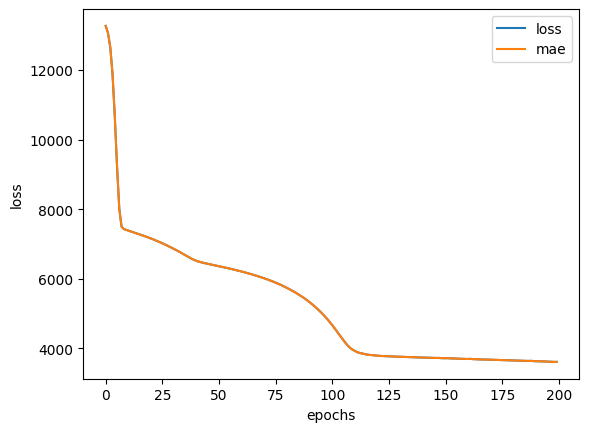

In [310]:
# Plot history also known as the loss curve or the training curve
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")

### Prprocessing Data (Normalization and Standardization)

In terms of scaling values, neural networks tend to prefer normaliztion.

If you are not sure on which to use, you could try both and see which performs better.

In [311]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Read in the insurance dataframe
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### To prepare our data we can borrow few classes from scikit learn

In [312]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Create a Column Transformer
ct = make_column_transformer(
    (MinMaxScaler(), ["age", "bmi", "children"]), #Turn all the values in these columns between 0 and 1
    (OneHotEncoder(handle_unknown="ignore"), ["sex", "smoker", "region"])
)

# Create our X and y values
X = insurance.drop("charges", axis=1)
y = insurance["charges"]

# Build our train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the column transformer on our training data
ct.fit(X_train)

# Transform training and test data with normalization(MinMaxScaler) and OneHotEncoder
X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)

In [313]:
# What does our data look like now?
X_train.loc[0]

,0
age,19
sex,female
bmi,27.9
children,0
smoker,yes
region,southwest


In [314]:
X_train_normal

array([[0.60869565, 0.10734463, 0.4       , ..., 1.        , 0.        ,
        0.        ],
       [0.63043478, 0.22491256, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.73913043, 0.23944041, 0.        , ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.86956522, 0.24791499, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.41304348, 0.85122411, 0.4       , ..., 0.        , 0.        ,
        1.        ],
       [0.80434783, 0.37503363, 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [315]:
X_train.shape, X_train_normal.shape

((1070, 6), (1070, 11))

Beautiful! Our data has been  normalized and one hot encoded. Now let's build a Neural network Model on it and see how it goes.

In [316]:
# Build a Neural Network Model to fit on our Normalized Data
tf.random.set_seed(42)

# Create a Model
insurance_model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# Compile the model
insurance_model_4.compile(loss = tf.keras.losses.mae,
                          optimizer = tf.keras.optimizers.Adam(),
                          metrics = ["mae"])

# Fit the model
insurance_model_4.fit(X_train_normal, y_train, epochs= 100, verbose=1)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 13343.0889 - mae: 13343.0889
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13333.9033 - mae: 13333.9033
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13312.3525 - mae: 13312.3525
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13268.2158 - mae: 13268.2158
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13190.3828 - mae: 13190.3828
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13067.7725 - mae: 13067.7725
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12889.8174 - mae: 12889.8174
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12646.3896 - mae: 12646.3896
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12327.6816 - mae: 12327.6816
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11928.1514 - mae: 11928.1514
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11455.2432 - mae: 11455.2432
Epoch 12/100
34/34 ━━━━━━━━━━━

In [317]:
# Evaluate our insurance model
insurance_model_4.evaluate(X_test_normal, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3432.4182 - mae: 3432.4182  


[3432.418212890625, 3432.418212890625]

In [318]:
X

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


<Axes: ylabel='Frequency'>

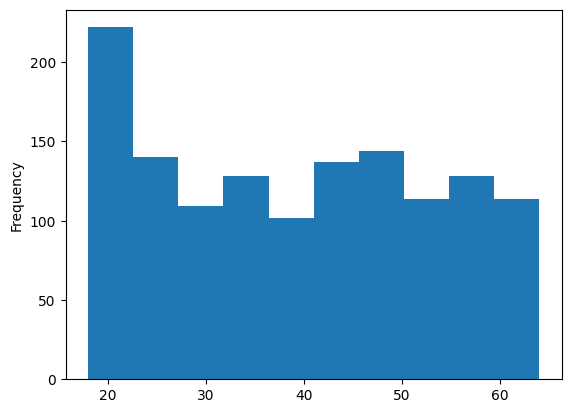

In [319]:
X["age"].plot(kind="hist")

<Axes: ylabel='Frequency'>

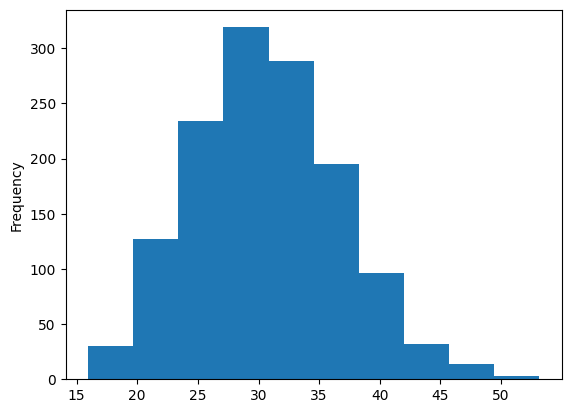

In [320]:
X["bmi"].plot(kind="hist")

In [321]:
X["children"].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18
